<a href="https://colab.research.google.com/github/jayx003/GenAI-Practice/blob/main/11_production_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production RAG Pipeline

We've learned the pieces. Today, we put them together.

**PDF → Chunking → Vector DB → Retrieval → LLM** — a complete RAG system.

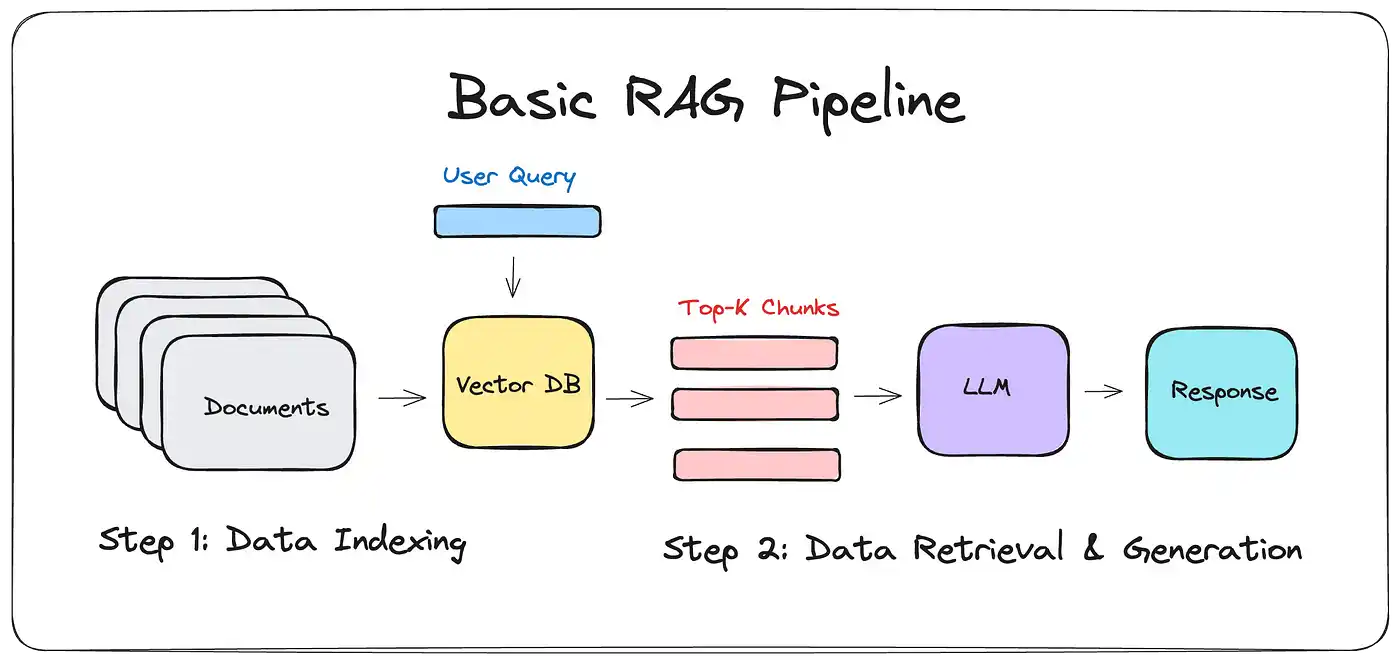

## Install PDF Library

In [2]:
%pip install PyPDF2 -q chromadb   # PyMuPDF pdfplumber unstrcutured.io

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/6

## Setup

In [4]:
from google import genai
import chromadb
from PyPDF2 import PdfReader
import os
from dotenv import load_dotenv

from google.colab import userdata
API_KEY = userdata.get('GEMINI_API_KEY')
# load_dotenv(dotenv_path='./.env')
# API_KEY = os.environ["GEMINI_API_KEY"]

client = genai.Client(api_key=API_KEY)

## Step 1: Load PDF

In [13]:
# Load PDF
pdf_path = "leave_policy.pdf"  # Your PDF file
reader = PdfReader(pdf_path)

# Extract text from all pages
full_text = ""   # empty string
for page in reader.pages:
    full_text += page.extract_text() + "\n"

print(f"📄 Loaded PDF: {len(reader.pages)} pages, {len(full_text)} characters")
print(f"\n📖 Preview:\n{full_text[:100]}...")

📄 Loaded PDF: 8 pages, 19644 characters

📖 Preview:
 
 Pride Global India Employee Leave Policy  
PRIDE Technologies Consulting (India) Private Limited ...


## Step 2: Chunk the Document

In [14]:
def chunk_text(text, chunk_size=500, overlap=50):
    """Split text into overlapping chunks."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()  # fixed chunking: 500 chars.
        if chunk:
            chunks.append(chunk)
        start = end - overlap   # 50 steps back  0-500  500-50 = 450
    return chunks

chunks = chunk_text(full_text)

print(f"✂️ Created {len(chunks)} chunks\n")
for i, chunk in enumerate(chunks[:3]):
    print(f"Chunk {i}: {chunk[:80]}...\n")

✂️ Created 44 chunks

Chunk 0: Pride Global India Employee Leave Policy  
PRIDE Technologies Consulting (India)...

Chunk 1: s and 
procedures to align 
with company and end 
client requirements  
 
 
  
V...

Chunk 2: ...........  3 
Public Holidays  ................................ .................



## Step 3: Store in Vector Database

In [15]:
# Create ChromaDB collection
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="pdf_store4")

# Generate embeddings and store
for i, chunk in enumerate(chunks):
    embedding = client.models.embed_content(
        model="gemini-embedding-001",
        contents=chunk
    ).embeddings[0].values

   # add chunks and embeddings in the chroma collection
    collection.add(
        documents=[chunk],
        embeddings=[embedding],
        ids=[f"chunk_{i}"]
    )

print(f"✅ Stored {collection.count()} chunks in ChromaDB")

✅ Stored 44 chunks in ChromaDB


## Step 4: The RAG Function

In [20]:
def ask(question):
    """Complete RAG pipeline: retrieve + generate."""

    # Embed the question
    query_emb = client.models.embed_content(
        model="gemini-embedding-001",
        contents=question
    ).embeddings[0].values

    # Retrieve relevant chunks
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=3
    )
    context = "\n\n".join(results['documents'][0])

    # Generate answer
    prompt = f"""Answer the question based ONLY on the context below.
If the answer is not in the context, say "I couldn't find that information."

Context:
{context}

Question: {question}

Answer:"""

    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=prompt
    )

    return response.text, results['documents'][0]

## Test: Ask Questions About the PDF

In [21]:
question = "Can you give me the details of Privilege leaves for Pune location?"

answer, sources = ask(question)

print(f"❓ {question}\n")
print(f"💬 {answer}\n")
print("📄 Sources:")
for i, src in enumerate(sources[1:]):
    print(f"  [{i+1}] {src[:100]}...")

❓ Can you give me the details of Privilege leaves for Pune location?

💬 For the Pune location, the details are as follows:

*   **Annual Privilege Leave Entitlement:** 18 days
*   **Maximum Accumulation Limit:** 45 days
*   **Monthly Credit Calculation:** 18/12 = 1.5 days per month

📄 Sources:
  [1] 12  12  
Mumbai  18  0  8  
Pune  18  0  8  
Gurgaon  18  7  7  
Noida  15  10  15  
Bangalore  18  ...
  [2] ing on a scheduled week -off first.  
Unused compensatory days off at the end of each year will laps...


In [ ]:
# Try your own questions!
question = input("Ask a question: ")
answer, sources = ask(question)
print(f"\n💬 {answer}")

## The Complete Pipeline

```
PDF → Extract Text → Chunk → Embed → Store in Vector DB
                                        ↓
Question → Embed → Search → Retrieve → LLM → Answer
```

## Key Takeaways

1. **Extract** text from PDFs using PyPDF2
2. **Chunk** with overlap to preserve context
3. **Store** embeddings in a vector database
4. **Retrieve** and **Generate** — that's RAG

---

This wraps up RAG basics. **Next section: Agents** — when retrieval isn't enough and you need to take actions.

# **What is Hallucination**
# **How to reduce or handle the hallucination**
# **If ur model is not giving you the expected answer then how to handle this problem??**

# **If we have pdf with text, image, table, image of table then how to embed this data/handle this case???**

# **If we have pdfs cvs excel image files in GB's then how to handle the embedding of this????**